# Wave 2 — Part 1: EDA Preparation
## Capstone Project — Student High School Dropout Prediction

**Dataset:** HSLS:09 (High School Longitudinal Study of 2009) — Wave 2 (11th Grade Follow-up)

**Purpose:** This notebook loads, merges, cleans, and inspects the Wave 2 data to produce  — a dataset ready for exploratory data analysis (EDA). Nominal variables are **not** encoded here, preserving original category labels for interpretable plots.


---
# Section 1 — Imports and Setup

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer

---
# Section 2 — Load Datasets

Two datasets are loaded at this stage:

- `original_dataset_withoutWieght_withoutNegativesInTarget.csv` — the full raw HSLS:09 dataset. Wave 2 columns are extracted from here.
- `Baseline_Dataset50.csv` — the cleaned and encoded Wave 1 dataset produced in the Wave 1 preprocessing notebook. This is the left side of the merge.


In [ ]:
original_df = pd.read_csv("original_dataset_withoutWieght_withoutNegativesInTarget.csv")
print(f"Original dataset shape: {original_df.shape}")

Original dataset shape: (17332, 3986)


In [ ]:
wave1 = pd.read_csv("Baseline_Dataset50.csv")
print(f"Wave 1 cleaned shape  : {wave1.shape}")
print(f"STU_ID present        : {'STU_ID' in wave1.columns}")

Wave 1 cleaned shape  : (15900, 51)
STU_ID present        : True


## 2.1 Verify Wave 1 — No Remaining Missing Values

The cleaned Wave 1 dataset should have no NaN values remaining. This check confirms the baseline before merging.

In [ ]:
missing_cols = wave1.columns[wave1.isna().any()].tolist()
if missing_cols:
    print(f"Columns with NaN in wave1:")
    for col in missing_cols:
        print(f"  {col}: {wave1[col].isna().sum()} missing")
else:
    print("Wave 1 dataset is fully clean — no missing values.")

Wave 1 dataset is fully clean — no missing values.


---
# Section 3 — Extract and Merge Wave 2 Columns

## 3.1 Define Wave 2 Column Set

All Wave 2 variables to be extracted from the original dataset are defined here, grouped by data type for clarity. The `STU_ID` column is included as the merge key.

In [ ]:
wave2_columns = [
    # Continuous — standardized scales and test scores
    "X2MTHEFF",       # Math self-efficacy scale (standardized)
    "X2SCIEFF",       # Science self-efficacy scale (standardized)
    "X2TXMTSCOR",     # Math standardized T-score (mean=50, SD=10)
    "X2BEHAVEIN",     # School motivation/behavior scale (standardized)
    "X2PROBLEM",      # School problems scale (standardized)
    "C2AVGACTENG",    "C2AVGACTMATH",   "C2AVGSATMATH",
    "C2AVGACTSCI",    "C2AVGACTCOMP",   "C2AVGSATREAD",
    "C2AVGACTREAD",   "C2AVGSATWRIT",

    # Ordinal — ordered categories
    "X2PAREDEXPCT",   # Parent education expectation (1-12 levels)
    "X2STUEDEXPCT",   # Student education expectation (1-12 levels)
    "S2GRD1011",      # Grade level 2010-2011 (1=9th to 4=12th)
    "S2GRD1112",      # Grade level 2011-2012 (1=9th to 4=12th)
    "X2REQLEVEL",     # Highest level meeting college requirements (0-5)
    "S2SUREDIPL",     # How sure of HS diploma (1=Very sure to 4=Won't get one)
    "S2ALG1GRADE",    # Final grade in Algebra I (1=A to 5=Below D)
    "S2EDUEXP",       # How far student expects to go (1-12 levels)
    "C2PCTEXAMINFO",  "C2PCTINFO",      "C2UPMCLGREQ",
    "C2UPMEOGEXAM",   "C2UPMGRADREQ",   "C2PCTEXAMPREP",
    "S2PAYOFF",       # Studying pays off belief (1=Strongly agree to 4=Strongly disagree)
    "S2DOOKAY",       # Can do okay as dropout belief (1=Strongly agree to 4=Strongly disagree)

    # Binary — yes/no variables
    "X2POVERTY",      # Below poverty threshold (0=No, 1=Yes)

    "C2AIDFLYER",     "C2GRADPLAN",     "C2INFOSESSN",
    "C2SELECTCLG",    "C2CLGAPP",       "C2INFSTEM",
    "S2ENROLLHS12",   # Spring 2012 enrollment status

    # Nominal — unordered categories
    "S2REQTYP4YR",    # Will meet requirements for typical 4-year college
    "S2CLG2013",      # Expects to continue education fall 2013
    "S2MOSTIMP2013",  # What parents think most important in fall 2013
    "X2ENROLSTAT",    # Enrollment status (used for row filtering, then dropped)
]

wave2_raw = original_df[['STU_ID'] + wave2_columns].copy()
print(f"Wave 2 raw shape  : {wave2_raw.shape}")
print(f"Columns extracted : {len(wave2_columns)}")
print(f"Unique students   : {wave2_raw['STU_ID'].nunique()}")

Wave 2 raw shape  : (17332, 42)
Columns extracted : 41
Unique students   : 17332


## 3.2 Check Student Overlap Between Waves

In [ ]:
only_in_w1 = set(wave1['STU_ID']) - set(wave2_raw['STU_ID'])
only_in_w2 = set(wave2_raw['STU_ID']) - set(wave1['STU_ID'])
in_both    = set(wave1['STU_ID']) & set(wave2_raw['STU_ID'])

print(f"Students in both waves : {len(in_both)}")
print(f"Only in Wave 1         : {len(only_in_w1)}")
print(f"Only in Wave 2         : {len(only_in_w2)}")

Students in both waves : 15900
Only in Wave 1         : 0
Only in Wave 2         : 1432


## 3.3 Merge Wave 1 and Wave 2

A left join on `STU_ID` is used. This keeps all rows from the cleaned Wave 1 dataset and attaches Wave 2 columns where a matching student exists. Students in Wave 1 who have no Wave 2 record will have NaN for all Wave 2 columns — these will be addressed during cleaning.

In [ ]:
combined = wave1.merge(wave2_raw, on='STU_ID', how='left')

print(f"Wave 1 shape     : {wave1.shape}")
print(f"Wave 2 raw shape : {wave2_raw.shape}")
print(f"Combined shape   : {combined.shape}")

assert len(combined) == len(wave1),     "Row count changed after merge — check for duplicate STU_IDs in wave2_raw"
print(f"Row count preserved: {len(combined)} rows")

Wave 1 shape     : (15900, 51)
Wave 2 raw shape : (17332, 42)
Combined shape   : (15900, 92)
Row count preserved: 15900 rows


## 3.4 Missing Rate Overview for Wave 2 Columns

Before any cleaning, we get a complete picture of how much data is present for each Wave 2 variable.

In [ ]:
sentinel_codes = [-9, -8, -7, -6, -5, -4]

print(f"  {'Column':<22} {'Valid%':>8} {'Missing%':>10}  Sentinels Found")
print(f"  {'─'*22} {'─'*8} {'─'*10}  {'─'*20}")

for col in wave2_columns:
    total          = len(combined)
    sentinel_count = combined[col].isin(sentinel_codes).sum()
    nan_count      = combined[col].isna().sum()
    total_missing  = sentinel_count + nan_count
    valid_pct      = (total - total_missing) / total * 100
    missing_pct    = total_missing / total * 100
    sents          = [str(c) for c in sentinel_codes if (combined[col] == c).sum() > 0]
    sents_str      = ', '.join(sents) if sents else 'None'
    print(f"  {col:<22} {valid_pct:>7.2f}% {missing_pct:>9.2f}%   {sents_str}")

  Column                   Valid%   Missing%  Sentinels Found
  ────────────────────── ──────── ──────────  ────────────────────
  X2MTHEFF                 89.48%     10.52%   -9, -8
  X2SCIEFF                 88.58%     11.42%   -9, -8
  X2TXMTSCOR               92.48%      7.52%   -8
  X2BEHAVEIN               89.92%     10.08%   -9, -8
  X2PROBLEM                77.65%     22.35%   -9, -8
  C2AVGACTENG              35.86%     64.14%   -9, -8, -6
  C2AVGACTMATH             35.90%     64.10%   -9, -8, -6
  C2AVGSATMATH             43.36%     56.64%   -9, -8, -6
  C2AVGACTSCI              35.55%     64.45%   -9, -8, -6
  C2AVGACTCOMP             47.82%     52.18%   -9, -8, -6
  C2AVGSATREAD             43.36%     56.64%   -9, -8, -6
  C2AVGACTREAD             35.62%     64.38%   -9, -8, -6
  C2AVGSATWRIT             41.91%     58.09%   -9, -8, -6
  X2PAREDEXPCT             93.60%      6.40%   -8
  X2STUEDEXPCT             92.48%      7.52%   -8
  S2GRD1011                91.45%      8.

---
# Section 4 — Filter Students: Remove Early Graduates and Dropouts

`X2ENROLSTAT` records the enrollment status of each student at the time of the Wave 2 survey. Certain codes indicate students who had already left the standard enrollment track before 11th grade — either by graduating early or by dropping out. Retaining these students would introduce noise into a model trained to predict dropout among students still on the standard path.

The codes removed are:

| Code | Meaning |
|------|---------|
| 4 | Early graduted |
| 5 | Dropout |
| 7 | Unknown status |
| 8 | Out of scope |

After filtering, `X2ENROLSTAT` is no longer needed and is dropped.

In [ ]:
values_to_remove = [4, 5, 7, 8]

wave2 = combined[~combined['X2ENROLSTAT'].isin(values_to_remove)].copy()

print(f"Combined shape   : {combined.shape}")
print(f"Filtered shape   : {wave2.shape}")
print(f"Rows removed     : {combined.shape[0] - wave2.shape[0]}")
print(f"\nRemaining X2ENROLSTAT value counts:")
print(wave2['X2ENROLSTAT'].value_counts().sort_index())

Combined shape   : (15900, 92)
Filtered shape   : (15236, 92)
Rows removed     : 664

Remaining X2ENROLSTAT value counts:
X2ENROLSTAT
1.0    12830
2.0     2154
3.0      195
6.0       57
Name: count, dtype: int64


In [ ]:
wave2 = wave2.drop(columns=['X2ENROLSTAT'])
print(f"Dropped X2ENROLSTAT. Shape: {wave2.shape}")

Dropped X2ENROLSTAT. Shape: (15236, 91)


---
# Section 5 — Variable Classification by Data Type

All Wave 2 variables are classified into four groups. This determines the correct cleaning, imputation, and encoding strategy for each variable.



In [ ]:
# Group 1 — Continuous
# Standardized PCA scales (mean=0, SD=1) and test scores
continuous_cols_w2 = [
    'X2MTHEFF',       # Math self-efficacy scale (standardized)
    'X2SCIEFF',       # Science self-efficacy scale (standardized)
    'X2TXMTSCOR',     # Math standardized T-score (mean=50, SD=10)
    'X2BEHAVEIN',     # School motivation/behavior scale (standardized)
    'X2PROBLEM',      # School problems scale (standardized)
    'C2AVGACTENG',    # Average ACT English score (school-level)
    'C2AVGACTMATH',   # Average ACT Math score (school-level)
    'C2AVGACTSCI',    # Average ACT Science score (school-level)
    'C2AVGACTCOMP',   # Average ACT Composite score (school-level)
    'C2AVGACTREAD',   # Average ACT Reading score (school-level)
    'C2AVGSATMATH',   # Average SAT Math score (school-level, 200-800)
    'C2AVGSATREAD',   # Average SAT Reading score (school-level, 200-800)
    'C2AVGSATWRIT',   # Average SAT Writing score (school-level, 200-800)
]

# Group 2 — Ordinal
# Ordered categories with meaningful rank
ordinal_cols_w2 = [
    'X2PAREDEXPCT',   # Parent education expectation (1-12 levels)
    'X2STUEDEXPCT',   # Student education expectation (1-12 levels)
    'S2GRD1011',      # Grade level in 2010-2011 (1=9th to 4=12th)
    'S2GRD1112',      # Grade level in 2011-2012 (1=9th to 4=12th)
    'X2REQLEVEL',     # Highest level meeting college requirements (0-5)
    'S2SUREDIPL',     # How sure of HS diploma (1=Very sure to 4=Won't get one)
    'S2ALG1GRADE',    # Final grade in Algebra I (1=A to 5=Below D)
    'S2EDUEXP',       # How far student expects to go in school (1-12 levels)
    'C2PCTEXAMINFO',  # % 11/12 graders given exam info (1=<5% to 6=75-100%)
    'C2PCTINFO',      # % 11/12 graders given college info (1=<5% to 6=75-100%)
    'C2UPMCLGREQ',    # Importance of college entry req for math placement (1-3)
    'C2UPMEOGEXAM',   # Importance of end-of-year exam for math placement (1-3)
    'C2UPMGRADREQ',   # Importance of grad requirements for math placement (1-3)
    'C2PCTEXAMPREP',  # % 11/12 graders given exam prep (1=<5% to 6=75-100%)
    'S2PAYOFF',       # Studying pays off belief (1=Strongly agree to 4=Strongly disagree)
    'S2DOOKAY',       # Can do okay as dropout belief (1=Strongly agree to 4=Strongly disagree)
]

# Group 3 — Binary
# Two-state variables (0/1 or 1/2)
binary_cols_w2 = [
    'X2POVERTY',      # Below poverty threshold (0=No, 1=Yes)
    'X2SEX',          # Student sex (1=Male, 2=Female) — excluded from modeling
    'C2AIDFLYER',     # School provides financial aid flyers (0=No, 1=Yes)
    'C2GRADPLAN',     # School plan includes graduation plan (0=No, 1=Yes)
    'C2INFOSESSN',    # School holds college info sessions (0=No, 1=Yes)
    'C2SELECTCLG',    # Counselor designated for college selection (0=No, 1=Yes)
    'C2CLGAPP',       # Counselor designated for college applications (0=No, 1=Yes)
    'C2INFSTEM',      # School informs parents about STEM careers (0=No, 1=Yes)
    'S2ENROLLHS12',   # Spring 2012 enrollment status (1=Attending, 2=Not, 3=Homeschool)
]

# Group 4 — Nominal
# Categories with no meaningful order
nominal_cols_w2 = [
    'S2REQTYP4YR',    # Will meet requirements for typical 4-year college (1=Yes, 2=No, 3=Don't Know)
    'S2CLG2013',      # Expects to continue education fall 2013 (1=Yes, 2=No, 3=Don't Know)
    'S2MOSTIMP2013',  # What parents think most important in fall 2013 (1-5 unordered)
]

print(f"Continuous : {len(continuous_cols_w2)} columns")
print(f"Ordinal    : {len(ordinal_cols_w2)} columns")
print(f"Binary     : {len(binary_cols_w2)} columns")
print(f"Nominal    : {len(nominal_cols_w2)} columns")

Continuous : 13 columns
Ordinal    : 16 columns
Binary     : 9 columns
Nominal    : 3 columns


---
# Section 6 — Data Cleaning by Variable Type

## 6.1 Continuous Variables

### Diagnostic — Sentinel and Missing Value Inspection

In [ ]:
sentinel_values = [-9, -8, -7, -6, -5, -4, -3]
total = len(wave2)

rows = []
for col in continuous_cols_w2:
    row = {'Column': col}
    for val in sentinel_values:
        count = (wave2[col] == val).sum()
        row[f'{val} (n)'] = count
        row[f'{val} (%)'] = round(count / total * 100, 2)
    missing = wave2[col].isna().sum()
    row['NaN (n)'] = missing
    row['NaN (%)'] = round(missing / total * 100, 2)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Column')
print("=== Continuous Columns — Sentinel and Missing Value Summary ===")
display(summary_df)

=== Continuous Columns — Sentinel and Missing Value Summary ===


,-9 (n),-9 (%),-8 (n),-8 (%),-7 (n),-7 (%),-6 (n),-6 (%),-5 (n),-5 (%),-4 (n),-4 (%),-3 (n),-3 (%),NaN (n),NaN (%)
Column,,,,,,,,,,,,,,,,
X2MTHEFF,433,2.84,920,6.04,0,0.0,0,0.00,0,0.0,0,0.0,0,0.00,0,0.0
X2SCIEFF,574,3.77,920,6.04,0,0.0,0,0.00,0,0.0,0,0.0,0,0.00,0,0.0
X2TXMTSCOR,0,0.00,920,6.04,0,0.0,0,0.00,0,0.0,0,0.0,0,0.00,0,0.0
X2BEHAVEIN,383,2.51,920,6.04,0,0.0,0,0.00,0,0.0,0,0.0,7,0.05,0,0.0
X2PROBLEM,2810,18.44,519,3.41,0,0.0,0,0.00,0,0.0,0,0.0,0,0.00,0,0.0
C2AVGACTENG,7271,47.72,108,0.71,0,0.0,2349,15.42,0,0.0,0,0.0,0,0.00,0,0.0
C2AVGACTMATH,7267,47.70,108,0.71,0,0.0,2349,15.42,0,0.0,0,0.0,0,0.00,0,0.0
C2AVGACTSCI,7320,48.04,108,0.71,0,0.0,2349,15.42,0,0.0,0,0.0,0,0.00,0,0.0
C2AVGACTCOMP,5440,35.70,108,0.71,0,0.0,2349,15.42,0,0.0,0,0.0,0,0.00,0,0.0


In [ ]:
print("Raw value inspection for continuous columns:")
print("=" * 70)
total_rows = len(wave2)

for col in continuous_cols_w2:
    count_minus9 = (wave2[col] == -9).sum()
    count_minus8 = (wave2[col] == -8).sum()
    count_minus7 = (wave2[col] == -7).sum()
    count_le_4   = (wave2[col] <= -4).sum()
    total_sentinel  = count_minus9 + count_minus8 + count_minus7
    already_nan     = wave2[col].isnull().sum()
    total_missing   = total_sentinel + already_nan

    print(f"\n{col}:")
    print(f"  Min / Max             : {wave2[col].min()} / {wave2[col].max()}")
    print(f"  Sentinel -9 (item)    : {count_minus9:>6} ({count_minus9/total_rows*100:.2f}%)")
    print(f"  Sentinel -8 (unit)    : {count_minus8:>6} ({count_minus8/total_rows*100:.2f}%)")
    print(f"  Sentinel -7 (skip)    : {count_minus7:>6} ({count_minus7/total_rows*100:.2f}%)")
    print(f"  Count <= -4 (any neg) : {count_le_4:>6} ({count_le_4/total_rows*100:.2f}%)")
    print(f"  Already NaN           : {already_nan:>6} ({already_nan/total_rows*100:.2f}%)")
    print(f"  TOTAL missing         : {total_missing:>6} ({total_missing/total_rows*100:.2f}%)")
    print(f"  Valid                 : {total_rows - total_missing:>6} ({(total_rows-total_missing)/total_rows*100:.2f}%)")
    print("-" * 50)

Raw value inspection for continuous columns:

X2MTHEFF:
  Min / Max             : -9.0 / 1.73
  Sentinel -9 (item)    :    433 (2.84%)
  Sentinel -8 (unit)    :    920 (6.04%)
  Sentinel -7 (skip)    :      0 (0.00%)
  Count <= -4 (any neg) :   1353 (8.88%)
  Already NaN           :      0 (0.00%)
  TOTAL missing         :   1353 (8.88%)
  Valid                 :  13883 (91.12%)
--------------------------------------------------

X2SCIEFF:
  Min / Max             : -9.0 / 1.64
  Sentinel -9 (item)    :    574 (3.77%)
  Sentinel -8 (unit)    :    920 (6.04%)
  Sentinel -7 (skip)    :      0 (0.00%)
  Count <= -4 (any neg) :   1494 (9.81%)
  Already NaN           :      0 (0.00%)
  TOTAL missing         :   1494 (9.81%)
  Valid                 :  13742 (90.19%)
--------------------------------------------------

X2TXMTSCOR:
  Min / Max             : -8.0 / 84.9051
  Sentinel -9 (item)    :      0 (0.00%)
  Sentinel -8 (unit)    :    920 (6.04%)
  Sentinel -7 (skip)    :      0 (0.00%)
  

### Filter — Retain Columns with at Least 90% Valid Values

Columns where more than 10% of values are missing (sentinel codes + NaN combined) are dropped. Imputing large proportions of a continuous variable introduces more noise than signal, particularly for standardized scales where the distribution shape matters.

In [ ]:
sentinel_codes = [-9, -8, -7, -6, -5, -4]

def valid_pct_continuous(col):
    total   = len(wave2[col])
    invalid = wave2[col].isin(sentinel_codes).sum() + wave2[col].isna().sum()
    return (1 - invalid / total) * 100

selected_continuous_cols = [col for col in continuous_cols_w2 if valid_pct_continuous(col) >= 90]
dropped_continuous_cols  = [col for col in continuous_cols_w2 if valid_pct_continuous(col) < 90]

print("Columns KEPT (>=90% valid):")
for col in selected_continuous_cols:
    print(f"  {col:<22}  ({valid_pct_continuous(col):.2f}% valid)")

print(f"\nColumns DROPPED (<90% valid):")
for col in dropped_continuous_cols:
    print(f"  {col:<22}  ({valid_pct_continuous(col):.2f}% valid)")

Columns KEPT (>=90% valid):
  X2MTHEFF                (91.12% valid)
  X2SCIEFF                (90.19% valid)
  X2TXMTSCOR              (93.96% valid)
  X2BEHAVEIN              (91.45% valid)

Columns DROPPED (<90% valid):
  X2PROBLEM               (78.15% valid)
  C2AVGACTENG             (36.15% valid)
  C2AVGACTMATH            (36.18% valid)
  C2AVGACTSCI             (35.83% valid)
  C2AVGACTCOMP            (48.17% valid)
  C2AVGACTREAD            (35.91% valid)
  C2AVGSATMATH            (44.04% valid)
  C2AVGSATREAD            (44.04% valid)
  C2AVGSATWRIT            (42.62% valid)


### Clean and Impute — Continuous Columns

Sentinel codes are replaced with NaN. Imputation uses the median, which is robust to skewed distributions — the appropriate strategy for standardized scales that may have asymmetric tails.

In [ ]:
wave2[selected_continuous_cols] = wave2[selected_continuous_cols].replace(sentinel_codes, np.nan)
print(f"Sentinel codes replaced with NaN in {len(selected_continuous_cols)} columns.")

imputer = SimpleImputer(strategy='median')
wave2[selected_continuous_cols] = imputer.fit_transform(wave2[selected_continuous_cols])
print(f"Median imputation applied.")

print("\n=== Post-Imputation Verification ===")
for col in selected_continuous_cols:
    nan_left      = wave2[col].isna().sum()
    sentinel_left = wave2[col].isin(sentinel_codes).sum()
    status        = "Clean" if nan_left == 0 and sentinel_left == 0 else "Issues remain"
    print(f"  {col:<22}  NaN: {nan_left}  Sentinels: {sentinel_left}  -> {status}")

cleaned_continuous_cols_w2 = selected_continuous_cols.copy()

Sentinel codes replaced with NaN in 4 columns.
Median imputation applied.

=== Post-Imputation Verification ===
  X2MTHEFF                NaN: 0  Sentinels: 0  -> Clean
  X2SCIEFF                NaN: 0  Sentinels: 0  -> Clean
  X2TXMTSCOR              NaN: 0  Sentinels: 0  -> Clean
  X2BEHAVEIN              NaN: 0  Sentinels: 0  -> Clean


---
## 6.2 Ordinal Variables

### Diagnostic — Sentinel and Missing Value Inspection

In [ ]:
sentinel_codes = [-9, -8, -7, -6, -5, -4]

print("=" * 70)
print("  ORDINAL COLUMNS — SENTINEL AND MISSING DIAGNOSTIC")
print("=" * 70)

for col in ordinal_cols_w2:
    total      = len(wave2[col])
    valid_mask = ~wave2[col].isin(sentinel_codes)
    valid_vals = wave2[col][valid_mask]
    valid_total = valid_mask.sum()

    print(f"\n  {col}")
    print(f"  Valid range   : {valid_vals.min()} to {valid_vals.max()}")
    print(f"  Valid count   : {valid_total} ({valid_total/total*100:.2f}%)")

    any_sentinel = False
    for code in sentinel_codes:
        count = (wave2[col] == code).sum()
        if count > 0:
            print(f"  Sentinel {code}  : {count} rows ({count/total*100:.2f}%)")
            any_sentinel = True
    if not any_sentinel:
        print(f"  No sentinels found")

    nan_count = wave2[col].isna().sum()
    print(f"  Already NaN   : {nan_count} ({nan_count/total*100:.2f}%)")

    print(f"  Value distribution (valid rows only):")
    val_counts = valid_vals.value_counts().sort_index()
    for val, count in val_counts.items():
        pct = count / valid_total * 100
        bar = '#' * int(pct / 2)
        print(f"    {val:>3} -> {count:>5} ({pct:>5.1f}%)  {bar}")

print(f"\n{'=' * 70}")
print("  SUMMARY TABLE")
print(f"{'=' * 70}")
print(f"  {'Column':<22} {'Valid%':>8} {'Missing%':>10}  Sentinels Found")
print(f"  {'─'*22} {'─'*8} {'─'*10}  {'─'*20}")

for col in ordinal_cols_w2:
    total          = len(wave2[col])
    valid_mask     = ~wave2[col].isin(sentinel_codes) & wave2[col].notna()
    valid_pct      = valid_mask.sum() / total * 100
    missing_pct    = 100 - valid_pct
    sents          = [str(c) for c in sentinel_codes if (wave2[col] == c).sum() > 0]
    sents_str      = ', '.join(sents) if sents else 'None'
    print(f"  {col:<22} {valid_pct:>7.2f}% {missing_pct:>9.2f}%   {sents_str}")

  ORDINAL COLUMNS — SENTINEL AND MISSING DIAGNOSTIC

  X2PAREDEXPCT
  Valid range   : 1.0 to 13.0
  Valid count   : 14460 (94.91%)
  Sentinel -8  : 776 rows (5.09%)
  Already NaN   : 0 (0.00%)
  Value distribution (valid rows only):
    1.0 ->    79 (  0.5%)  
    2.0 ->   849 (  5.9%)  ##
    3.0 ->    40 (  0.3%)  
    4.0 ->   685 (  4.7%)  ##
    5.0 ->   106 (  0.7%)  
    6.0 ->  1024 (  7.1%)  ###
    7.0 ->   163 (  1.1%)  
    8.0 ->  4404 ( 30.5%)  ###############
    9.0 ->   101 (  0.7%)  
    10.0 ->  2924 ( 20.2%)  ##########
    11.0 ->   129 (  0.9%)  
    12.0 ->  2432 ( 16.8%)  ########
    13.0 ->  1524 ( 10.5%)  #####

  X2STUEDEXPCT
  Valid range   : 1.0 to 13.0
  Valid count   : 14316 (93.96%)
  Sentinel -8  : 920 rows (6.04%)
  Already NaN   : 0 (0.00%)
  Value distribution (valid rows only):
    1.0 ->    39 (  0.3%)  
    2.0 ->   928 (  6.5%)  ###
    3.0 ->    61 (  0.4%)  
    4.0 ->   633 (  4.4%)  ##
    5.0 ->   103 (  0.7%)  
    6.0 ->  1183 (  8.3%)  #

### Filter and Clean — Ordinal Columns

As with continuous variables, columns with less than 90% valid values are dropped. Remaining columns have sentinel codes replaced with NaN and are imputed using the mode, which is the appropriate measure of central tendency for ordinal data.

In [ ]:
def valid_pct(col):
    total   = len(wave2[col])
    invalid = wave2[col].isin(sentinel_codes).sum() + wave2[col].isna().sum()
    return (1 - invalid / total) * 100

selected_ordinal_cols = [col for col in ordinal_cols_w2 if valid_pct(col) >= 90]
dropped_ordinal_cols  = [col for col in ordinal_cols_w2 if valid_pct(col) < 90]

print("Columns KEPT (>=90% valid):")
for col in selected_ordinal_cols:
    print(f"  {col:<22}  ({valid_pct(col):.2f}% valid)")

print(f"\nColumns DROPPED (<90% valid):")
for col in dropped_ordinal_cols:
    print(f"  {col:<22}  ({valid_pct(col):.2f}% valid)")

wave2[selected_ordinal_cols] = wave2[selected_ordinal_cols].replace(sentinel_codes, np.nan)

imputer = SimpleImputer(strategy='most_frequent')
wave2[selected_ordinal_cols] = imputer.fit_transform(wave2[selected_ordinal_cols])

print(f"\n=== Post-Imputation Verification ===")
for col in selected_ordinal_cols:
    nan_left      = wave2[col].isna().sum()
    sentinel_left = wave2[col].isin(sentinel_codes).sum()
    status        = "Clean" if nan_left == 0 and sentinel_left == 0 else "Issues remain"
    print(f"  {col:<22}  NaN: {nan_left}  Sentinels: {sentinel_left}  -> {status}")

cleaned_ordinal_cols_w2 = selected_ordinal_cols.copy()
print(f"\nCleaned ordinal columns ({len(cleaned_ordinal_cols_w2)}): {cleaned_ordinal_cols_w2}")

Columns KEPT (>=90% valid):
  X2PAREDEXPCT            (94.91% valid)
  X2STUEDEXPCT            (93.96% valid)
  S2GRD1011               (93.31% valid)
  S2GRD1112               (93.11% valid)
  X2REQLEVEL              (93.50% valid)
  S2SUREDIPL              (93.39% valid)
  S2ALG1GRADE             (90.91% valid)
  S2EDUEXP                (93.90% valid)
  S2PAYOFF                (92.07% valid)
  S2DOOKAY                (92.02% valid)

Columns DROPPED (<90% valid):
  C2PCTEXAMINFO           (82.06% valid)
  C2PCTINFO               (81.85% valid)
  C2UPMCLGREQ             (67.31% valid)
  C2UPMEOGEXAM            (68.00% valid)
  C2UPMGRADREQ            (67.89% valid)
  C2PCTEXAMPREP           (74.60% valid)

=== Post-Imputation Verification ===
  X2PAREDEXPCT            NaN: 0  Sentinels: 0  -> Clean
  X2STUEDEXPCT            NaN: 0  Sentinels: 0  -> Clean
  S2GRD1011               NaN: 0  Sentinels: 0  -> Clean
  S2GRD1112               NaN: 0  Sentinels: 0  -> Clean
  X2REQLEVEL       

---
## 6.3 Binary Variables

### Diagnostic — Sentinel Inspection and Class Balance

In [ ]:
sentinel_codes = [-9, -8, -7, -6, -5, -4]

print("=" * 70)
print("  BINARY COLUMNS — SENTINEL AND MISSING DIAGNOSTIC")
print("=" * 70)

for col in binary_cols_w2:
    total      = len(wave2[col])
    valid_mask = ~wave2[col].isin(sentinel_codes) & wave2[col].notna()
    valid_vals = wave2[col][valid_mask]
    valid_total = valid_mask.sum()

    print(f"\n  {col}")
    print(f"  Valid range  : {int(valid_vals.min())} to {int(valid_vals.max())}")
    print(f"  Valid count  : {valid_total} ({valid_total/total*100:.2f}%)")

    any_sentinel = False
    for code in sentinel_codes:
        count = (wave2[col] == code).sum()
        if count > 0:
            print(f"  Sentinel {code}: {count} rows ({count/total*100:.2f}%)")
            any_sentinel = True
    if not any_sentinel:
        print(f"  No sentinels found")

    val_counts   = valid_vals.value_counts().sort_index()
    if len(val_counts) == 2:
        minority_pct = val_counts.min() / valid_total * 100
        majority_pct = val_counts.max() / valid_total * 100
        balance_note = "IMBALANCED" if minority_pct < 10 else "Balanced"
        print(f"  Balance      : {majority_pct:.1f}% / {minority_pct:.1f}% [{balance_note}]")

print(f"\n{'=' * 70}")
print("  SUMMARY TABLE")
print(f"{'=' * 70}")
print(f"  {'Column':<22} {'Valid%':>8} {'Missing%':>10}  Sentinels")
print(f"  {'─'*22} {'─'*8} {'─'*10}  {'─'*20}")

for col in binary_cols_w2:
    total          = len(wave2[col])
    valid_mask     = ~wave2[col].isin(sentinel_codes) & wave2[col].notna()
    valid_total    = valid_mask.sum()
    valid_pct_val  = valid_total / total * 100
    missing_pct    = 100 - valid_pct_val
    sents          = [str(c) for c in sentinel_codes if (wave2[col] == c).sum() > 0]
    sents_str      = ', '.join(sents) if sents else 'None'
    print(f"  {col:<22} {valid_pct_val:>7.2f}% {missing_pct:>9.2f}%   {sents_str}")

  BINARY COLUMNS — SENTINEL AND MISSING DIAGNOSTIC

  X2POVERTY
  Valid range  : 0 to 1
  Valid count  : 14460 (94.91%)
  Sentinel -8: 776 rows (5.09%)
  Balance      : 85.1% / 14.9% [Balanced]

  X2SEX
  Valid range  : 1 to 2
  Valid count  : 15236 (100.00%)
  No sentinels found
  Balance      : 51.4% / 48.6% [Balanced]

  C2AIDFLYER
  Valid range  : 0 to 1
  Valid count  : 12673 (83.18%)
  Sentinel -9: 106 rows (0.70%)
  Sentinel -8: 108 rows (0.71%)
  Sentinel -6: 2349 rows (15.42%)
  Balance      : 96.5% / 3.5% [IMBALANCED]

  C2GRADPLAN
  Valid range  : 0 to 1
  Valid count  : 9175 (60.22%)
  Sentinel -9: 17 rows (0.11%)
  Sentinel -8: 108 rows (0.71%)
  Sentinel -7: 3587 rows (23.54%)
  Sentinel -6: 2349 rows (15.42%)
  Balance      : 93.3% / 6.7% [IMBALANCED]

  C2INFOSESSN
  Valid range  : 0 to 1
  Valid count  : 12717 (83.47%)
  Sentinel -9: 62 rows (0.41%)
  Sentinel -8: 108 rows (0.71%)
  Sentinel -6: 2349 rows (15.42%)
  Balance      : 93.8% / 6.2% [IMBALANCED]

  C2SELECTC

### Filter and Clean — Binary Columns

`X2SEX` is excluded from modeling (sex is not a target-relevant predictor in this study) but retained in the dataset for reference. The remaining binary columns with at least 90% valid values are cleaned and imputed using the mode.

In [ ]:
exclude_cols = ['X2SEX']

def valid_pct_binary(col):
    total   = len(wave2[col])
    invalid = wave2[col].isin(sentinel_codes).sum() + wave2[col].isna().sum()
    return (1 - invalid / total) * 100

selected_binary_cols = [
    col for col in binary_cols_w2
    if col not in exclude_cols and valid_pct_binary(col) >= 90
]
dropped_binary_cols = [
    col for col in binary_cols_w2
    if col not in exclude_cols and valid_pct_binary(col) < 90
]

print("Columns KEPT (>=90% valid, excluding X2SEX):")
for col in selected_binary_cols:
    print(f"  {col:<22}  ({valid_pct_binary(col):.2f}% valid)")

print(f"\nColumns DROPPED (<90% valid):")
for col in dropped_binary_cols:
    print(f"  {col:<22}  ({valid_pct_binary(col):.2f}% valid)")

wave2[selected_binary_cols] = wave2[selected_binary_cols].replace(sentinel_codes, np.nan)

imputer = SimpleImputer(strategy='most_frequent')
wave2[selected_binary_cols] = imputer.fit_transform(wave2[selected_binary_cols])

print(f"\n=== Post-Imputation Verification ===")
for col in selected_binary_cols:
    nan_left      = wave2[col].isna().sum()
    sentinel_left = wave2[col].isin(sentinel_codes).sum()
    status        = "Clean" if nan_left == 0 and sentinel_left == 0 else "Issues remain"
    print(f"  {col:<22}  NaN: {nan_left}  Sentinels: {sentinel_left}  -> {status}")

cleaned_binary_cols_w2 = selected_binary_cols.copy()
print(f"\nCleaned binary columns ({len(cleaned_binary_cols_w2)}): {cleaned_binary_cols_w2}")

Columns KEPT (>=90% valid, excluding X2SEX):
  X2POVERTY               (94.91% valid)
  S2ENROLLHS12            (93.96% valid)

Columns DROPPED (<90% valid):
  C2AIDFLYER              (83.18% valid)
  C2GRADPLAN              (60.22% valid)
  C2INFOSESSN             (83.47% valid)
  C2SELECTCLG             (83.51% valid)
  C2CLGAPP                (83.09% valid)
  C2INFSTEM               (83.62% valid)

=== Post-Imputation Verification ===
  X2POVERTY               NaN: 0  Sentinels: 0  -> Clean
  S2ENROLLHS12            NaN: 0  Sentinels: 0  -> Clean

Cleaned binary columns (2): ['X2POVERTY', 'S2ENROLLHS12']


---
## 6.4 Nominal Variables

### Diagnostic — Sentinel Inspection

In [ ]:
sentinel_codes = [-9, -8, -7, -6, -5, -4]

print("=" * 70)
print("  NOMINAL COLUMNS — SENTINEL AND MISSING DIAGNOSTIC")
print("=" * 70)

for col in nominal_cols_w2:
    total      = len(wave2[col])
    valid_mask = ~wave2[col].isin(sentinel_codes)
    valid_vals = wave2[col][valid_mask]
    valid_total = valid_mask.sum()

    print(f"\n  {col}")
    print(f"  Valid range   : {valid_vals.min()} to {valid_vals.max()}")
    print(f"  Valid count   : {valid_total} ({valid_total/total*100:.2f}%)")

    for code in sentinel_codes:
        count = (wave2[col] == code).sum()
        if count > 0:
            print(f"  Sentinel {code}  : {count} rows ({count/total*100:.2f}%)")

    print(f"  Value distribution (valid rows only):")
    val_counts = valid_vals.value_counts().sort_index()
    for val, count in val_counts.items():
        pct = count / valid_total * 100
        print(f"    {val:>3} -> {count:>5} ({pct:.1f}%)")

  NOMINAL COLUMNS — SENTINEL AND MISSING DIAGNOSTIC

  S2REQTYP4YR
  Valid range   : 1.0 to 3.0
  Valid count   : 14100 (92.54%)
  Sentinel -9  : 216 rows (1.42%)
  Sentinel -8  : 920 rows (6.04%)
  Value distribution (valid rows only):
    1.0 -> 10739 (76.2%)
    2.0 ->  1176 (8.3%)
    3.0 ->  2185 (15.5%)

  S2CLG2013
  Valid range   : 1.0 to 3.0
  Valid count   : 14298 (93.84%)
  Sentinel -9  : 18 rows (0.12%)
  Sentinel -8  : 920 rows (6.04%)
  Value distribution (valid rows only):
    1.0 -> 12770 (89.3%)
    2.0 ->   675 (4.7%)
    3.0 ->   853 (6.0%)

  S2MOSTIMP2013
  Valid range   : 1.0 to 5.0
  Valid count   : 14228 (93.38%)
  Sentinel -9  : 88 rows (0.58%)
  Sentinel -8  : 920 rows (6.04%)
  Value distribution (valid rows only):
    1.0 -> 12564 (88.3%)
    2.0 ->   911 (6.4%)
    3.0 ->   262 (1.8%)
    4.0 ->    50 (0.4%)
    5.0 ->   441 (3.1%)


### Check Whether Nominal -8 Rows Are Structurally Linked

Before creating a missingness flag, we verify whether the same rows have -8 across all three nominal columns. If they do, one binary flag captures the entire unit non-response pattern for this group.

In [ ]:
nom_cols = ['S2REQTYP4YR', 'S2CLG2013', 'S2MOSTIMP2013']

mask_all_8 = (
    (wave2['S2REQTYP4YR']  == -8) &
    (wave2['S2CLG2013']    == -8) &
    (wave2['S2MOSTIMP2013']== -8)
)
print(f"Rows where all three nominal columns are -8: {mask_all_8.sum()}")
print("If this equals the -8 count for each column individually, one flag is sufficient.")

Rows where all three nominal columns are -8: 920
If this equals the -8 count for each column individually, one flag is sufficient.


---
# Section 7 — Outlier Inspection for Continuous Variables

## 7.1 Why Outliers Are Retained

After imputation, we inspect the distribution of all continuous columns using boxplots. Statistical outliers — data points beyond 1.5 times the interquartile range from the box edges — are identified but **not removed or capped**.

The decision to retain outliers rests on three grounds:

**1. These are standardized scales, not raw measurements.**
`X2MTHEFF`, `X2SCIEFF`, `X2BEHAVEIN`, and `X2PROBLEM` are standardized composite scores computed by NCES using principal component analysis. Extreme values at either tail are mathematically valid scores representing students at the ends of the measured distribution. They are not recording errors.

**2. Outliers in this dataset correspond to high-risk students.**
A student with an extremely low school motivation score (`X2BEHAVEIN`) or an extremely high school problems score (`X2PROBLEM`) is precisely the type of student the model is designed to identify. Removing or compressing these scores would reduce the model's ability to distinguish the highest-risk students from the rest.


**Conclusion:** Outliers are acknowledged and documented here, but no capping, Winsorization, or removal is applied. They represent genuine variation in student behavior and academic standing.

In [ ]:
def plot_boxplot(df, cols, title="Continuous Columns — Outlier Inspection", n_cols=3):
    """
    Plot boxplots with outlier statistics for a list of continuous columns.

    How to read the output:
        Box        = middle 50% of data (IQR = Q3 - Q1)
        Red line   = median
        Whiskers   = 1.5 * IQR from box edges
        Dots       = statistical outliers beyond the whiskers

    Columns where outliers exceed 5% of valid rows are flagged.
    No values are removed — flagging is for documentation only.
    """
    n_rows = math.ceil(len(cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax   = axes[i]
        data = df[col].dropna()

        Q1       = data.quantile(0.25)
        Q3       = data.quantile(0.75)
        IQR      = Q3 - Q1
        lower    = Q1 - 1.5 * IQR
        upper    = Q3 + 1.5 * IQR
        outliers = data[(data < lower) | (data > upper)]
        out_pct  = len(outliers) / len(data) * 100

        ax.boxplot(
            data, vert=True, patch_artist=True,
            boxprops    = dict(facecolor='steelblue', alpha=0.6),
            medianprops = dict(color='red', linewidth=2),
            flierprops  = dict(marker='o', color='tomato', markersize=3, alpha=0.4),
            whiskerprops= dict(color='steelblue', linewidth=1.5),
            capprops    = dict(color='steelblue', linewidth=1.5)
        )

        stats_text = (
            f'Min    : {data.min():.3f}\n'
            f'Q1     : {Q1:.3f}\n'
            f'Median : {data.median():.3f}\n'
            f'Q3     : {Q3:.3f}\n'
            f'Max    : {data.max():.3f}\n'
            f'IQR    : {IQR:.3f}\n'
            f'Lower  : {lower:.3f}\n'
            f'Upper  : {upper:.3f}\n'
            f'Outliers: {len(outliers)} ({out_pct:.2f}%)'
        )
        ax.text(1.05, 0.5, stats_text, transform=ax.transAxes, fontsize=8,
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        label = f'{col} [REVIEW]' if out_pct > 5 else col
        color  = 'red' if out_pct > 5 else 'black'
        ax.set_title(label, fontsize=10, fontweight='bold', color=color)
        if out_pct > 5:
            ax.set_facecolor('#fff8f8')
        ax.set_ylabel('Value')
        ax.set_xticks([])

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 7.2 Boxplot Inspection — All Continuous Variables

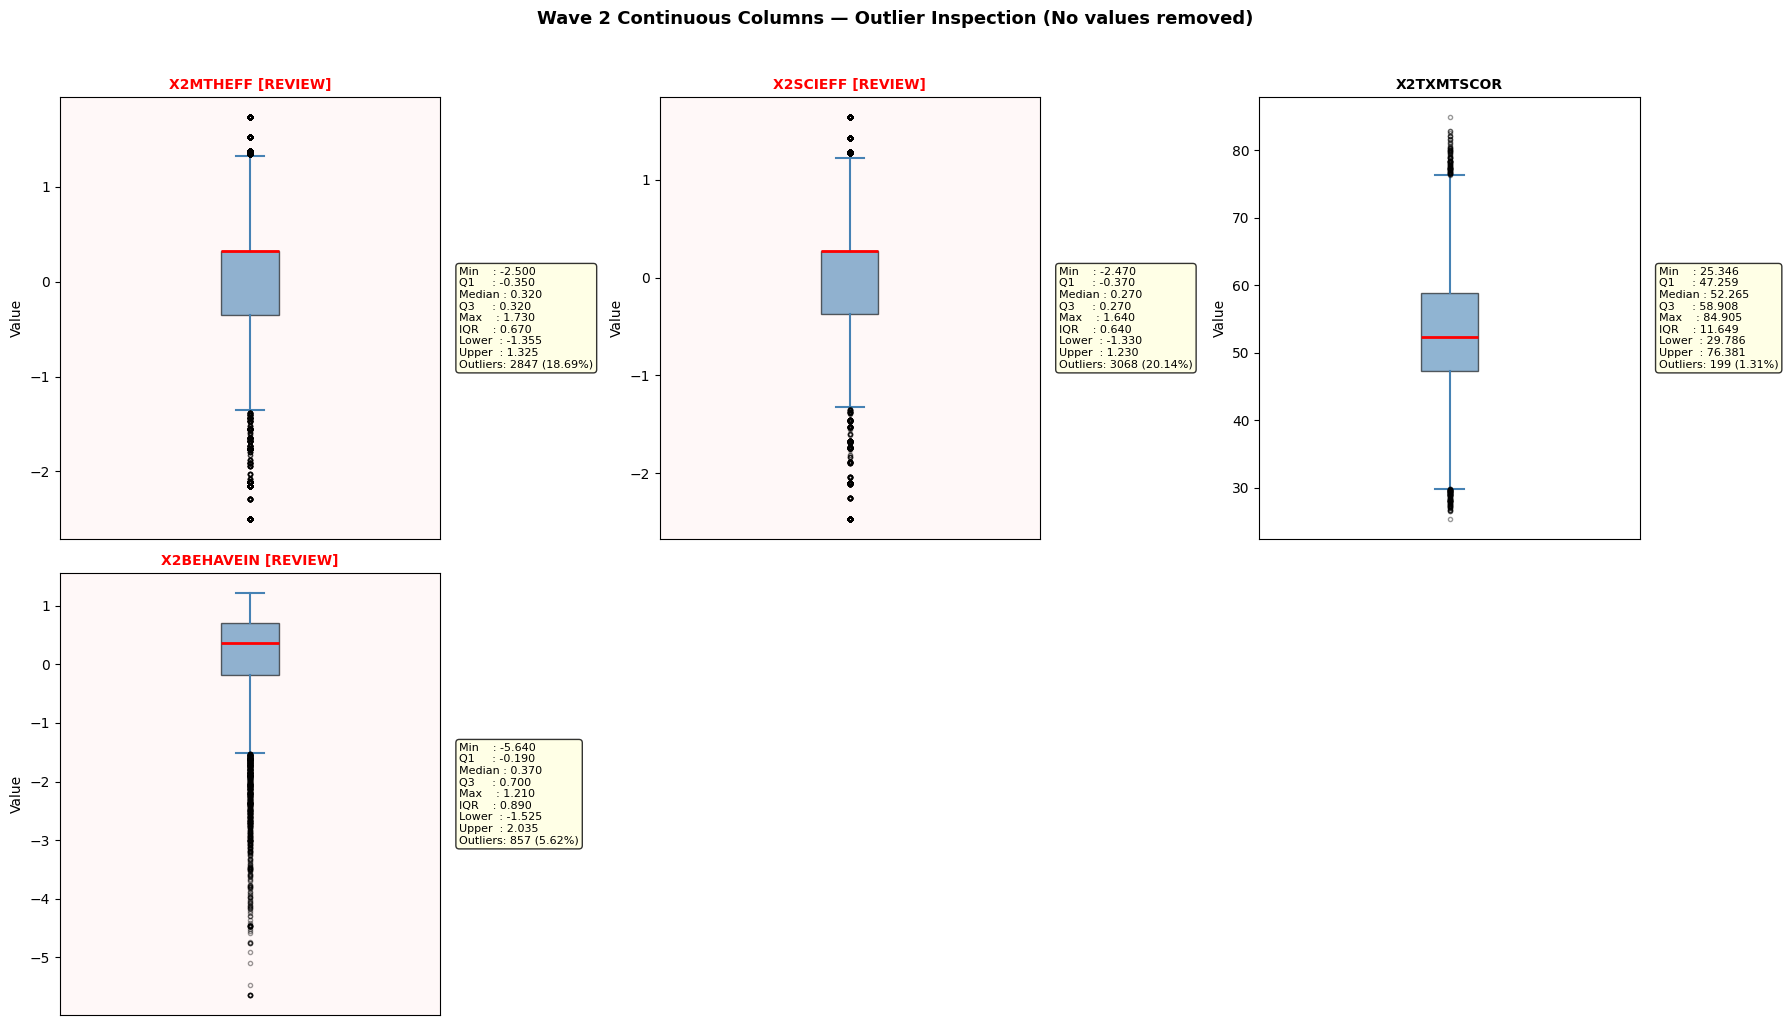

In [ ]:
plot_boxplot(
    df    = wave2,
    cols  = cleaned_continuous_cols_w2,
    title = 'Wave 2 Continuous Columns — Outlier Inspection (No values removed)'
)

## 7.3 Outlier Summary Table

This table documents the outlier count and percentage for each continuous column. All outliers are retained.

In [ ]:
print(f"  {'Column':<22} {'Min':>8} {'Max':>8} {'Outliers':>10} {'%':>8}  Decision")
print(f"  {'─'*22} {'─'*8} {'─'*8} {'─'*10} {'─'*8}  {'─'*20}")

for col in cleaned_continuous_cols_w2:
    data     = wave2[col].dropna()
    Q1       = data.quantile(0.25)
    Q3       = data.quantile(0.75)
    IQR      = Q3 - Q1
    lower    = Q1 - 1.5 * IQR
    upper    = Q3 + 1.5 * IQR
    outliers = data[(data < lower) | (data > upper)]
    out_pct  = len(outliers) / len(data) * 100
    note     = "Review" if out_pct > 5 else "Retain"
    print(f"  {col:<22} {data.min():>8.2f} {data.max():>8.2f} {len(outliers):>10} {out_pct:>7.2f}%  {note} (real scores)")

  Column                      Min      Max   Outliers        %  Decision
  ────────────────────── ──────── ──────── ────────── ────────  ────────────────────
  X2MTHEFF                  -2.50     1.73       2847   18.69%  Review (real scores)
  X2SCIEFF                  -2.47     1.64       3068   20.14%  Review (real scores)
  X2TXMTSCOR                25.35    84.91        199    1.31%  Retain (real scores)
  X2BEHAVEIN                -5.64     1.21        857    5.62%  Review (real scores)


---
# Section 8 — Create EDA-Ready Dataset (Before Encoding)


Before applying one-hot encoding to the nominal columns, a snapshot of the current dataset is saved. This version preserves nominal variables in their original integer category form, which is appropriate for EDA visualizations where the raw category labels are more interpretable than sparse dummy columns.



In [ ]:

wave2_eda = wave2

wave2_eda.to_csv("Wave2_EDA_Ready.csv", index=False)
print(f"Saved: Wave2_EDA_Ready.csv")
print(f"  Shape  : {wave2_eda.shape}")
print(f"  Note   : Nominal columns are in integer category form — suitable for EDA before encoding")

Saved: Wave2_EDA_Ready.csv
  Shape  : (15236, 91)
  Note   : Nominal columns are in integer category form — suitable for EDA before encoding
